# Reinforcement Learning — MDPs e Dynamic Programming

Este notebook segue a estrutura dos slides enviados sobre **Sutton & Barto — Capítulos 3 e 4**, cobrindo:

1. Interface agente–ambiente  
2. Processos de Decisão de Markov finitos (FMDP)  
3. Função de probabilidade $$p(s', r \mid s, a)$$  
4. Retorno $$G_t$$, fator de desconto $$\gamma$$ e episódios  
5. Políticas determinísticas e estocásticas  
6. Função valor $$v_\pi(s)$$ e função ação-valor $$q_\pi(s,a)$$  
7. Policy Evaluation  
8. Policy Improvement  
9. Policy Iteration  
10. Value Iteration  

A ideia é combinar formulação matemática com exemplos executáveis em Python.

## 1. Interface agente–ambiente

Em aprendizado por reforço, o agente interage com o ambiente em passos discretos de tempo.

No tempo $t$:

- o agente observa um estado $S_t$;
- escolhe uma ação $A_t$;
- o ambiente retorna uma recompensa $R_{t+1}$;
- o ambiente muda para um novo estado $S_{t+1}$.

A política do agente é representada por:

$$
\pi(a \mid s) = \Pr(A_t=a \mid S_t=s)
$$

O objetivo é encontrar uma política que maximize o retorno esperado.

## 2. Processo de Decisão de Markov Finito

Um MDP finito pode ser definido por:

$$
\mathcal{M} = (\mathcal{S}, \mathcal{A}, p, \gamma)
$$

onde:

- $\mathcal{S}$: conjunto finito de estados;
- $\mathcal{A}$: conjunto finito de ações;
- $p(s', r \mid s, a)$: dinâmica do ambiente;
- $\gamma \in [0,1]$: fator de desconto.

A função mais geral usada por Sutton & Barto é:

$$
p(s', r \mid s, a)
=
\Pr(S_t=s', R_t=r \mid S_{t-1}=s, A_{t-1}=a)
$$

Para cada par $$(s,a)$$, a soma das probabilidades sobre todos os próximos estados e recompensas possíveis deve ser 1:

$$
\sum_{s' \in \mathcal{S}} \sum_{r \in \mathcal{R}}
p(s', r \mid s, a) = 1
$$

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 3. Exemplo simples de FMDP: “Trabalhar ou procrastinar”

Vamos criar um MDP inspirado no exemplo dos slides.

Estados:

- `HR`: Happy and Rich
- `HP`: Happy and Poor
- `SR`: Sad and Rich

Ações:

- `P`: procrastinate
- `W`: work

A tabela abaixo define transições do tipo:

$$
(s, a) \rightarrow (s', r, p)
$$

In [ ]:
states = ["HR", "HP", "SR"]
actions = ["P", "W"]

# Cada entrada: (estado_atual, ação): [(próximo_estado, recompensa, probabilidade), ...]
mdp = {
    ("HR", "P"): [("HP", +10, 1.0)],
    ("HR", "W"): [("SR", -10, 1.0)],
    ("HP", "P"): [("HP", +10, 1.0)],
    ("HP", "W"): [("SR", -10, 0.8), ("HR", +100, 0.2)],
    ("SR", "W"): [("SR", -10, 1.0)],
    ("SR", "P"): [("HP", +10, 1.0)],
}

rows = []
for (s, a), transitions in mdp.items():
    for s_next, r, p in transitions:
        rows.append({
            "state": s,
            "action": a,
            "next_state": s_next,
            "reward": r,
            "probability": p,
        })

df_mdp = pd.DataFrame(rows)
df_mdp

,state,action,next_state,reward,probability
0,HR,P,HP,10,1.0
1,HR,W,SR,-10,1.0
2,HP,P,HP,10,1.0
3,HP,W,SR,-10,0.8
4,HP,W,HR,100,0.2
5,SR,W,SR,-10,1.0
6,SR,P,HP,10,1.0


### Verificando se a dinâmica é válida

Para cada par $$(s,a)$$, precisamos ter:

$$
\sum_{s',r} p(s',r \mid s,a)=1
$$

In [ ]:
prob_sum = df_mdp.groupby(["state", "action"])["probability"].sum()
prob_sum

state  action
HP     P         1.0
       W         1.0
HR     P         1.0
       W         1.0
SR     P         1.0
       W         1.0
Name: probability, dtype: float64

In [ ]:
assert np.allclose(prob_sum.values, 1.0), "Existe algum par (s,a) cuja soma de probabilidades não é 1"
print("Todas as distribuições p(s', r | s, a) são válidas.")

Todas as distribuições p(s', r | s, a) são válidas.


## 4. Obtendo $p(s' \mid s,a)$, $r(s,a)$ e $r(s,a,s')$

A partir da função mais geral:

$
p(s', r \mid s,a)
$

podemos obter a probabilidade de transição:

$
p(s' \mid s,a) = \sum_{r \in \mathcal{R}} p(s', r \mid s,a)
$

A recompensa esperada para um par estado–ação:

$
r(s,a) =
\mathbb{E}[R_t \mid S_{t-1}=s, A_{t-1}=a]
=
\sum_{s',r} r \, p(s', r \mid s,a)
$

E a recompensa esperada condicionada ao próximo estado:

$
r(s,a,s') =
\sum_{r \in \mathcal{R}}
r \,
\frac{p(s', r \mid s,a)}{p(s' \mid s,a)}
$

In [ ]:
def transition_probability(df):
    return (
        df.groupby(["state", "action", "next_state"])["probability"]
        .sum()
        .reset_index()
        .rename(columns={"probability": "P(s_next|s,a)"})
    )

def expected_reward_sa(df):
    df_tmp = df.copy()
    df_tmp["r_times_p"] = df_tmp["reward"] * df_tmp["probability"]
    return (
        df_tmp.groupby(["state", "action"])["r_times_p"]
        .sum()
        .reset_index()
        .rename(columns={"r_times_p": "r(s,a)"})
    )

def expected_reward_sas(df):
    # Como neste exemplo cada (s,a,s') tem uma única recompensa, o resultado fica direto.
    # O código também funciona se existirem várias recompensas para o mesmo próximo estado.
    df_tmp = df.copy()
    p_next = transition_probability(df_tmp)
    merged = df_tmp.merge(p_next, on=["state", "action", "next_state"])
    merged["weighted_reward"] = merged["reward"] * merged["probability"] / merged["P(s_next|s,a)"]
    return (
        merged.groupby(["state", "action", "next_state"])["weighted_reward"]
        .sum()
        .reset_index()
        .rename(columns={"weighted_reward": "r(s,a,s_next)"})
    )

transition_probability(df_mdp)

,state,action,next_state,"P(s_next|s,a)"
0,HP,P,HP,1.0
1,HP,W,HR,0.2
2,HP,W,SR,0.8
3,HR,P,HP,1.0
4,HR,W,SR,1.0
5,SR,P,HP,1.0
6,SR,W,SR,1.0


In [ ]:
expected_reward_sa(df_mdp)

,state,action,"r(s,a)"
0,HP,P,10.0
1,HP,W,12.0
2,HR,P,10.0
3,HR,W,-10.0
4,SR,P,10.0
5,SR,W,-10.0


In [ ]:
expected_reward_sas(df_mdp)

,state,action,next_state,"r(s,a,s_next)"
0,HP,P,HP,10.0
1,HP,W,HR,100.0
2,HP,W,SR,-10.0
3,HR,P,HP,10.0
4,HR,W,SR,-10.0
5,SR,P,HP,10.0
6,SR,W,SR,-10.0


## 5. Propriedade de Markov

A propriedade de Markov diz que o futuro depende apenas do estado atual e da ação atual, não de todo o histórico.

Sem a hipótese de Markov, poderíamos ter:

$$
\Pr(S_{t+1}, R_{t+1} \mid S_0,A_0,R_1,\ldots,S_t,A_t)
$$

Com a propriedade de Markov:

$$
\Pr(S_{t+1}, R_{t+1} \mid S_0,A_0,R_1,\ldots,S_t,A_t)
=
\Pr(S_{t+1}, R_{t+1} \mid S_t,A_t)
$$

Isso é o que permite representar o ambiente por $$p(s',r \mid s,a)$$.

## 6. Retorno $$G_t$$

Em tarefas episódicas, o retorno pode ser escrito como:

$$
G_t = R_{t+1} + R_{t+2} + \cdots + R_T
$$

Em tarefas contínuas ou descontadas:

$$
G_t
=
R_{t+1}
+
\gamma R_{t+2}
+
\gamma^2 R_{t+3}
+
\cdots
=
\sum_{k=0}^{\infty}\gamma^k R_{t+k+1}
$$

A forma recursiva é:

$$
G_t = R_{t+1} + \gamma G_{t+1}
$$

Quanto mais $$\gamma$$ se aproxima de 1, mais o agente considera recompensas futuras.

In [ ]:
def compute_returns_backward(rewards, gamma):
    """
    rewards = [R1, R2, ..., RT]
    retorna [G0, G1, ..., GT]
    com GT = 0.
    """
    G = 0.0
    returns = [0.0] * (len(rewards) + 1)
    returns[-1] = 0.0

    for t in reversed(range(len(rewards))):
        G = rewards[t] + gamma * G
        returns[t] = G

    return returns

rewards = [-1, 2, 6, 3, 2]
gamma = 0.5

returns = compute_returns_backward(rewards, gamma)
for t, g in enumerate(returns):
    print(f"G{t} = {g:.3f}")

G0 = 2.000
G1 = 6.000
G2 = 8.000
G3 = 4.000
G4 = 2.000
G5 = 0.000


### Comparando diferentes valores de $$\gamma$$

Vamos observar como o peso $$\gamma^k$$ decai ao longo do tempo.

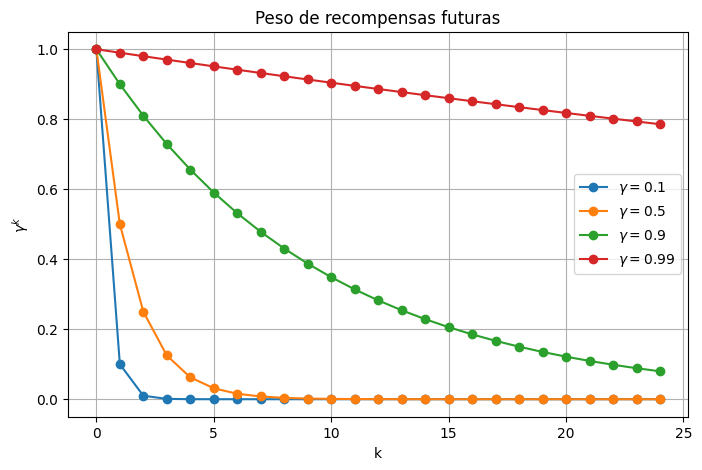

In [ ]:
ks = np.arange(0, 25)
gammas = [0.1, 0.5, 0.9, 0.99]

plt.figure(figsize=(8, 5))
for g in gammas:
    plt.plot(ks, g ** ks, marker="o", label=fr"$\gamma={g}$")

plt.xlabel("k")
plt.ylabel(r"$\gamma^k$")
plt.title("Peso de recompensas futuras")
plt.legend()
plt.grid(True)
plt.show()

## 7. Grid World: modelando o problema como FMDP

Vamos construir um Grid World simples.

- O agente começa em uma posição inicial;
- pode mover para cima, baixo, esquerda ou direita;
- recebe $$-1$$ por passo;
- recebe $$+1$$ ao chegar em um objetivo;
- a célula preta é bloqueada;
- se bater na parede ou no obstáculo, permanece no mesmo estado.

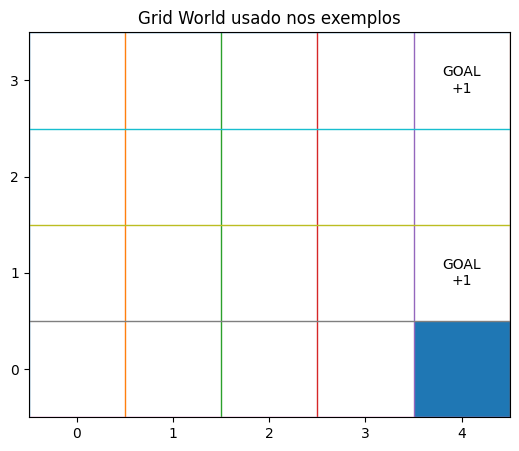

In [ ]:
class GridWorld:
    def __init__(self, width=5, height=4, start=(0, 0), goals={(4, 1), (4, 3)}, obstacles={(4, 0)}):
        self.width = width
        self.height = height
        self.start = start
        self.goals = set(goals)
        self.obstacles = set(obstacles)
        self.actions = ["U", "D", "L", "R"]
        self.action_delta = {
            "U": (0, 1),
            "D": (0, -1),
            "L": (-1, 0),
            "R": (1, 0),
        }

        self.states = [
            (x, y)
            for y in range(height)
            for x in range(width)
            if (x, y) not in self.obstacles
        ]

    def is_terminal(self, state):
        return state in self.goals

    def step_model(self, state, action):
        """
        Modelo determinístico: retorna [(next_state, reward, probability)].
        """
        if self.is_terminal(state):
            return [(state, 0.0, 1.0)]

        dx, dy = self.action_delta[action]
        x, y = state
        next_state = (x + dx, y + dy)

        # Parede ou obstáculo: fica parado
        if (
            next_state[0] < 0 or next_state[0] >= self.width or
            next_state[1] < 0 or next_state[1] >= self.height or
            next_state in self.obstacles
        ):
            next_state = state

        reward = +1.0 if next_state in self.goals else -1.0
        return [(next_state, reward, 1.0)]

    def draw_values(self, V=None, policy=None, title="Grid World"):
        fig, ax = plt.subplots(figsize=(7, 5))

        for x in range(self.width + 1):
            ax.plot([x, x], [0, self.height], linewidth=1)
        for y in range(self.height + 1):
            ax.plot([0, self.width], [y, y], linewidth=1)

        for obs in self.obstacles:
            ax.add_patch(plt.Rectangle(obs, 1, 1))

        for g in self.goals:
            ax.text(g[0] + 0.5, g[1] + 0.5, "GOAL\n+1", ha="center", va="center", fontsize=10)

        if V is not None:
            for s, v in V.items():
                if s in self.goals or s in self.obstacles:
                    continue
                ax.text(s[0] + 0.5, s[1] + 0.65, f"{v:.2f}", ha="center", va="center", fontsize=9)

        if policy is not None:
            arrow = {"U": "↑", "D": "↓", "L": "←", "R": "→"}
            for s, a in policy.items():
                if s in self.goals or s in self.obstacles:
                    continue
                ax.text(s[0] + 0.5, s[1] + 0.35, arrow[a], ha="center", va="center", fontsize=16)

        ax.set_xlim(0, self.width)
        ax.set_ylim(0, self.height)
        ax.set_aspect("equal")
        ax.set_xticks(np.arange(self.width) + 0.5)
        ax.set_yticks(np.arange(self.height) + 0.5)
        ax.set_xticklabels(range(self.width))
        ax.set_yticklabels(range(self.height))
        ax.set_title(title)
        plt.show()

grid = GridWorld()
grid.draw_values(title="Grid World usado nos exemplos")

## 8. Política

Uma política define como o agente escolhe ações.

Política determinística:

$$
\pi(s) = a
$$

Política estocástica:

$$
\pi(a \mid s) = \Pr(A_t=a \mid S_t=s)
$$

Em uma política uniforme:

$$
\pi(a \mid s) = \frac{1}{|\mathcal{A}|}
$$

In [ ]:
def uniform_random_policy(env):
    return {
        s: {a: 1.0 / len(env.actions) for a in env.actions}
        for s in env.states
    }

def deterministic_policy_to_stochastic(env, deterministic_policy):
    pi = {}
    for s in env.states:
        pi[s] = {a: 0.0 for a in env.actions}
        if s in deterministic_policy:
            pi[s][deterministic_policy[s]] = 1.0
        else:
            # fallback: uniforme
            for a in env.actions:
                pi[s][a] = 1.0 / len(env.actions)
    return pi

pi_uniform = uniform_random_policy(grid)

# Exemplo: probabilidade das ações em um estado específico
pi_uniform[(2, 1)]

{'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25}

## 9. Simulando uma trajetória e calculando o retorno

Vamos simular uma política manual que tenta chegar no objetivo inferior em $$(4,1)$$.

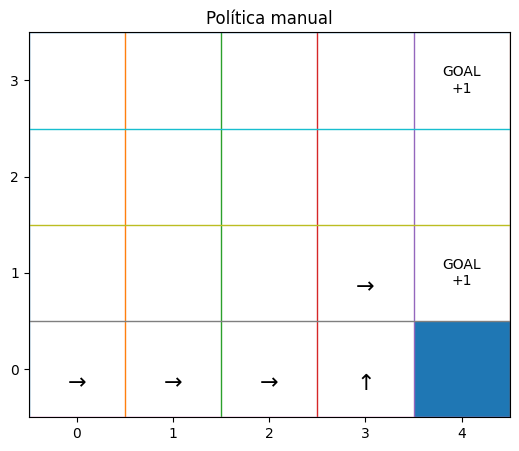

([(0, 0), (1, 0), (2, 0), (3, 0), (3, 1), (4, 1)],
 [-1.0, -1.0, -1.0, -1.0, 1.0],
 -3.0)

In [ ]:
manual_policy = {
    (0, 0): "R",
    (1, 0): "R",
    (2, 0): "R",
    (3, 0): "U",  # evita obstáculo em (4,0)
    (3, 1): "R",
}

grid.draw_values(policy=manual_policy, title="Política manual")

def simulate_deterministic_policy(env, policy, max_steps=20):
    s = env.start
    trajectory = [s]
    rewards = []

    for _ in range(max_steps):
        if env.is_terminal(s):
            break

        a = policy.get(s, np.random.choice(env.actions))
        s_next, r, _ = env.step_model(s, a)[0]
        rewards.append(r)
        trajectory.append(s_next)
        s = s_next

    return trajectory, rewards

trajectory, rewards = simulate_deterministic_policy(grid, manual_policy)
trajectory, rewards, sum(rewards)

In [ ]:
gamma = 1.0
returns = compute_returns_backward(rewards, gamma)
print("Trajetória:", trajectory)
print("Recompensas:", rewards)
print("Retorno G0:", returns[0])

Trajetória: [(0, 0), (1, 0), (2, 0), (3, 0), (3, 1), (4, 1)]
Recompensas: [-1.0, -1.0, -1.0, -1.0, 1.0]
Retorno G0: -3.0


## 10. Função valor $v_\pi(s)$

A função valor de estado é o retorno esperado começando em $s$ e seguindo a política $\pi$:

$
v_\pi(s)
=
\mathbb{E}_\pi[G_t \mid S_t=s]
$

Usando a equação de Bellman:

$
v_\pi(s)
=
\sum_a \pi(a \mid s)
\sum_{s',r}
p(s',r \mid s,a)
\left[
r + \gamma v_\pi(s')
\right]
$

Essa equação combina duas fontes de aleatoriedade:

1. a política $\pi(a \mid s)$;
2. a dinâmica do ambiente $p(s',r \mid s,a)$.

## 11. Exemplo com 2 estados: resolvendo por sistema linear

Considere:

$$
\pi(a_1 \mid s_1)=0.5,
\quad
\pi(a_2 \mid s_1)=0.5
$$

$$
\pi(a_1 \mid s_2)=0.8,
\quad
\pi(a_2 \mid s_2)=0.2
$$

Transições determinísticas:

| Estado | Ação | Próximo estado | Recompensa |
|---|---|---|---|
| $$s_1$$ | $$a_1$$ | $$s_1$$ | 0 |
| $$s_1$$ | $$a_2$$ | $$s_2$$ | 1 |
| $$s_2$$ | $$a_1$$ | $$s_1$$ | 2 |
| $$s_2$$ | $$a_2$$ | $$s_2$$ | 0 |

Com $$\gamma=0.9$$, temos:

$$
v_\pi(s_1)=0.5[0+0.9v_\pi(s_1)] + 0.5[1+0.9v_\pi(s_2)]
$$

$$
v_\pi(s_2)=0.8[2+0.9v_\pi(s_1)] + 0.2[0+0.9v_\pi(s_2)]
$$

In [ ]:
gamma = 0.9

# Sistema A x = b, onde x = [v(s1), v(s2)]
# v1 = 0.45 v1 + 0.5 + 0.45 v2
# v2 = 1.6 + 0.72 v1 + 0.18 v2
#
# 0.55 v1 - 0.45 v2 = 0.5
# -0.72 v1 + 0.82 v2 = 1.6

A = np.array([
    [0.55, -0.45],
    [-0.72, 0.82],
])
b = np.array([0.5, 1.6])

v = np.linalg.solve(A, b)
print(f"v_pi(s1) = {v[0]:.3f}")
print(f"v_pi(s2) = {v[1]:.3f}")

v_pi(s1) = 8.898
v_pi(s2) = 9.764


## 12. Policy Evaluation iterativa

Em vez de resolver o sistema linear diretamente, podemos estimar $$v_\pi(s)$$ iterativamente.

Inicializamos arbitrariamente:

$$
V_0(s)=0
$$

e repetimos:

$$
V_{k+1}(s)
=
\sum_a \pi(a \mid s)
\sum_{s',r}
p(s',r \mid s,a)
\left[
r+\gamma V_k(s')
\right]
$$

até convergir.

Convergiu em 146 iterações


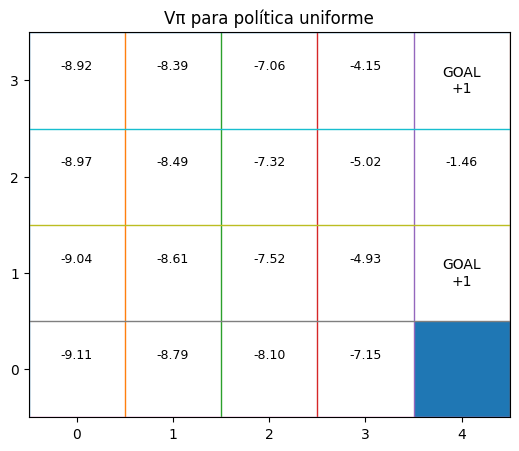

In [ ]:
def policy_evaluation(env, pi, gamma=0.9, theta=1e-8, max_iterations=10_000):
    V = {s: 0.0 for s in env.states}
    history = []

    for iteration in range(max_iterations):
        delta = 0.0
        V_new = V.copy()

        for s in env.states:
            if env.is_terminal(s):
                V_new[s] = 0.0
                continue

            v = 0.0
            for a, action_prob in pi[s].items():
                for s_next, r, p in env.step_model(s, a):
                    v += action_prob * p * (r + gamma * V[s_next])

            delta = max(delta, abs(v - V[s]))
            V_new[s] = v

        V = V_new
        history.append(delta)

        if delta < theta:
            break

    return V, history

V_uniform, history_uniform = policy_evaluation(grid, pi_uniform, gamma=0.9)

print(f"Convergiu em {len(history_uniform)} iterações")
grid.draw_values(V_uniform, title="Vπ para política uniforme")

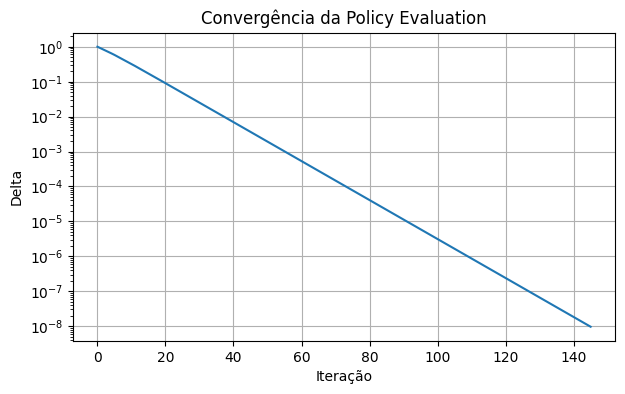

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history_uniform)
plt.yscale("log")
plt.xlabel("Iteração")
plt.ylabel("Delta")
plt.title("Convergência da Policy Evaluation")
plt.grid(True)
plt.show()

## 13. Exemplo pequeno de Policy Evaluation

Transições:

| Estado | Ação | Próximo estado | Recompensa | Prob. |
|---|---|---|---|---|
| $$s_1$$ | $$a_1$$ | $$s_1$$ | 0 | 1 |
| $$s_1$$ | $$a_2$$ | $$s_2$$ | 2 | 1 |
| $$s_2$$ | $$a_1$$ | $$T$$ | 1 | 1 |
| $$s_2$$ | $$a_2$$ | $$s_2$$ | 0 | 1 |

Política:

$
\pi(a_1 \mid s_1)=0.5,\quad
\pi(a_2 \mid s_1)=0.5
$

$
\pi(a_1 \mid s_2)=1,\quad
\pi(a_2 \mid s_2)=0
$

Com $\gamma = 0.9$ e $V(T)=0$.

In [ ]:
small_states = ["s1", "s2", "T"]
small_actions = ["a1", "a2"]

small_mdp = {
    ("s1", "a1"): [("s1", 0.0, 1.0)],
    ("s1", "a2"): [("s2", 2.0, 1.0)],
    ("s2", "a1"): [("T", 1.0, 1.0)],
    ("s2", "a2"): [("s2", 0.0, 1.0)],
    ("T", "a1"): [("T", 0.0, 1.0)],
    ("T", "a2"): [("T", 0.0, 1.0)],
}

small_pi = {
    "s1": {"a1": 0.5, "a2": 0.5},
    "s2": {"a1": 1.0, "a2": 0.0},
    "T": {"a1": 0.5, "a2": 0.5},
}

def evaluate_small_mdp(num_iterations=6, gamma=0.9):
    V = {s: 0.0 for s in small_states}
    rows = [{"iteration": 0, "V(s1)": V["s1"], "V(s2)": V["s2"], "V(T)": V["T"]}]

    for k in range(1, num_iterations + 1):
        V_new = V.copy()

        for s in small_states:
            if s == "T":
                V_new[s] = 0.0
                continue

            total = 0.0
            for a, pi_prob in small_pi[s].items():
                for s_next, r, p in small_mdp[(s, a)]:
                    total += pi_prob * p * (r + gamma * V[s_next])
            V_new[s] = total

        V = V_new
        rows.append({"iteration": k, "V(s1)": V["s1"], "V(s2)": V["s2"], "V(T)": V["T"]})

    return pd.DataFrame(rows)

df_eval = evaluate_small_mdp(num_iterations=10)
df_eval

,iteration,V(s1),V(s2),V(T)
0,0,0.000000,0.0,0.0
1,1,1.000000,1.0,0.0
2,2,1.900000,1.0,0.0
3,3,2.305000,1.0,0.0
4,4,2.487250,1.0,0.0
5,5,2.569262,1.0,0.0
6,6,2.606168,1.0,0.0
7,7,2.622776,1.0,0.0
8,8,2.630249,1.0,0.0
9,9,2.633612,1.0,0.0


## 14. Função ação-valor $q_\pi(s,a)$

A função ação-valor representa o retorno esperado após tomar a ação $a$ no estado $s$ e, depois disso, seguir a política $\pi$:

$
q_\pi(s,a)
=
\sum_{s',r}
p(s',r \mid s,a)
\left[
r + \gamma v_\pi(s')
\right]
$

Ela é útil para melhorar uma política.

In [ ]:
def compute_q_from_v(env, V, gamma=0.9):
    Q = {}
    for s in env.states:
        Q[s] = {}
        for a in env.actions:
            q = 0.0
            for s_next, r, p in env.step_model(s, a):
                q += p * (r + gamma * V[s_next])
            Q[s][a] = q
    return Q

Q_uniform = compute_q_from_v(grid, V_uniform, gamma=0.9)

# Mostrando Q para alguns estados
for s in [(0, 0), (2, 1), (3, 1)]:
    print(s, Q_uniform[s])

(0, 0) {'U': -9.136341656231785, 'D': -9.200122034210356, 'L': -9.200122034210356, 'R': -8.908401127930981}
(2, 1) {'U': -7.586459067471171, 'D': -8.28842417980757, 'L': -8.751502146860549, 'R': -5.435078037908386}
(3, 1) {'U': -5.515286888093475, 'D': -7.432341807202937, 'L': -7.7638292666725075, 'R': 1.0}


## 15. Policy Improvement

Depois de avaliar uma política, podemos melhorá-la escolhendo, em cada estado, a ação com maior $q_\pi(s,a)$:

$
\pi'(s) = \arg\max_a q_\pi(s,a)
$

Isso gera uma política gulosa em relação à função valor atual.

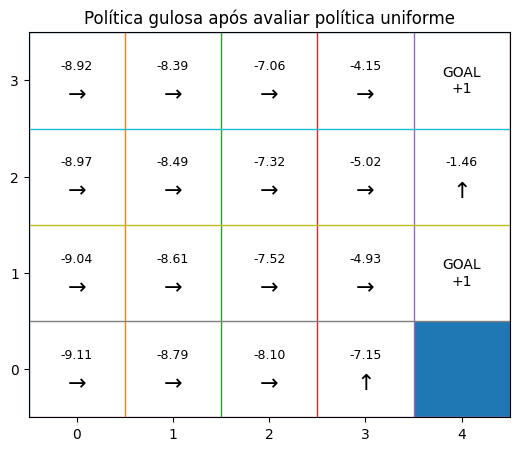

In [ ]:
def greedy_policy_from_q(env, Q):
    deterministic_policy = {}
    for s in env.states:
        if env.is_terminal(s):
            continue
        best_action = max(Q[s], key=Q[s].get)
        deterministic_policy[s] = best_action
    return deterministic_policy

greedy_policy = greedy_policy_from_q(grid, Q_uniform)
grid.draw_values(V_uniform, greedy_policy, title="Política gulosa após avaliar política uniforme")

## 16. Policy Iteration

A policy iteration alterna entre:

1. **Policy Evaluation**: calcula $v_\pi(s)$;
2. **Policy Improvement**: atualiza a política para ser gulosa em relação a $q_\pi(s,a)$.

O processo se repete até a política não mudar mais.

Policy Iteration convergiu em 3 iterações


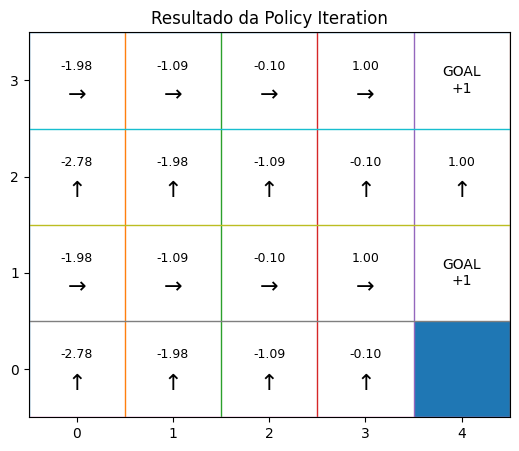

In [ ]:
def policy_iteration(env, gamma=0.9, theta=1e-8, max_iterations=100):
    # Começa com política uniforme
    pi = uniform_random_policy(env)
    deterministic_policy = {}

    for i in range(max_iterations):
        V, _ = policy_evaluation(env, pi, gamma=gamma, theta=theta)
        Q = compute_q_from_v(env, V, gamma=gamma)
        new_deterministic_policy = greedy_policy_from_q(env, Q)

        stable = new_deterministic_policy == deterministic_policy
        deterministic_policy = new_deterministic_policy
        pi = deterministic_policy_to_stochastic(env, deterministic_policy)

        if stable:
            return V, deterministic_policy, i + 1

    return V, deterministic_policy, max_iterations

V_pi_opt, policy_pi_opt, n_iter = policy_iteration(grid, gamma=0.9)

print(f"Policy Iteration convergiu em {n_iter} iterações")
grid.draw_values(V_pi_opt, policy_pi_opt, title="Resultado da Policy Iteration")

## 17. Valores ótimos e Equação de Bellman ótima

A função valor ótima é:

$$
v_*(s)
=
\max_a
\sum_{s',r}
p(s',r \mid s,a)
\left[
r + \gamma v_*(s')
\right]
$$

A função ação-valor ótima é:

$$
q_*(s,a)
=
\sum_{s',r}
p(s',r \mid s,a)
\left[
r + \gamma \max_{a'} q_*(s',a')
\right]
$$

Depois de obter $$q_*(s,a)$$, a política ótima pode ser obtida por:

$$
\pi_*(s) = \arg\max_a q_*(s,a)
$$

## 18. Value Iteration

A value iteration aplica diretamente a atualização ótima:

$$
V_{k+1}(s)
=
\max_a
\sum_{s',r}
p(s',r \mid s,a)
\left[
r+\gamma V_k(s')
\right]
$$

Após a convergência, extraímos a política gulosa.

Value Iteration convergiu em 6 iterações


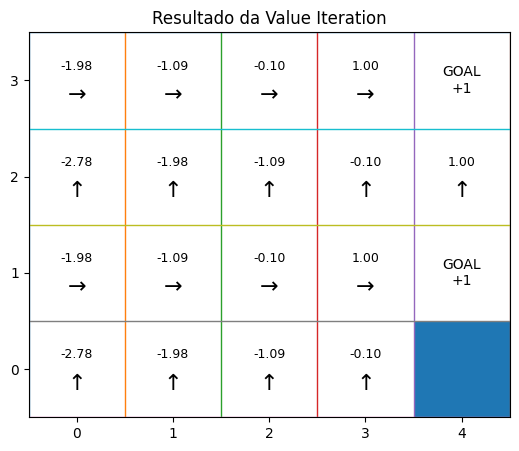

In [ ]:
def value_iteration(env, gamma=0.9, theta=1e-8, max_iterations=10_000):
    V = {s: 0.0 for s in env.states}
    history = []

    for iteration in range(max_iterations):
        delta = 0.0
        V_new = V.copy()

        for s in env.states:
            if env.is_terminal(s):
                V_new[s] = 0.0
                continue

            action_values = []
            for a in env.actions:
                q = 0.0
                for s_next, r, p in env.step_model(s, a):
                    q += p * (r + gamma * V[s_next])
                action_values.append(q)

            best_v = max(action_values)
            delta = max(delta, abs(best_v - V[s]))
            V_new[s] = best_v

        V = V_new
        history.append(delta)

        if delta < theta:
            break

    Q = compute_q_from_v(env, V, gamma=gamma)
    policy = greedy_policy_from_q(env, Q)
    return V, policy, history

V_vi, policy_vi, history_vi = value_iteration(grid, gamma=0.9)

print(f"Value Iteration convergiu em {len(history_vi)} iterações")
grid.draw_values(V_vi, policy_vi, title="Resultado da Value Iteration")

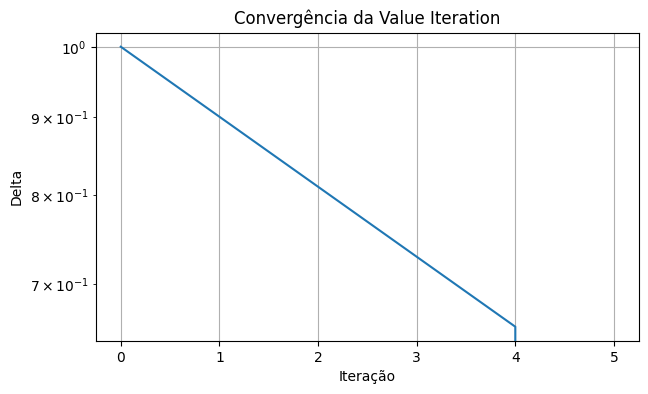

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history_vi)
plt.yscale("log")
plt.xlabel("Iteração")
plt.ylabel("Delta")
plt.title("Convergência da Value Iteration")
plt.grid(True)
plt.show()

## 19. Comparando Policy Iteration e Value Iteration

Ambos os métodos usam o modelo completo do ambiente.

| Método | Ideia |
|---|---|
| Policy Evaluation | calcula $$v_\pi$$ para uma política fixa |
| Policy Improvement | melhora a política usando $$q_\pi$$ |
| Policy Iteration | alterna avaliação e melhoria |
| Value Iteration | faz atualização ótima diretamente com $$\max_a$$ |

Em problemas pequenos, ambos funcionam bem. Em problemas grandes, guardar todos os estados e transições pode se tornar inviável.

In [ ]:
comparison = pd.DataFrame({
    "state": list(V_vi.keys()),
    "V_policy_iteration": [V_pi_opt[s] for s in V_vi.keys()],
    "V_value_iteration": [V_vi[s] for s in V_vi.keys()],
    "policy_iteration_action": [policy_pi_opt.get(s, "-") for s in V_vi.keys()],
    "value_iteration_action": [policy_vi.get(s, "-") for s in V_vi.keys()],
})

comparison.sort_values("state")

,state,V_policy_iteration,V_value_iteration,policy_iteration_action,value_iteration_action
0,"(0, 0)",-2.7829,-2.7829,U,U
4,"(0, 1)",-1.9810,-1.9810,R,R
9,"(0, 2)",-2.7829,-2.7829,U,U
14,"(0, 3)",-1.9810,-1.9810,R,R
1,"(1, 0)",-1.9810,-1.9810,U,U
5,"(1, 1)",-1.0900,-1.0900,R,R
10,"(1, 2)",-1.9810,-1.9810,U,U
15,"(1, 3)",-1.0900,-1.0900,R,R
2,"(2, 0)",-1.0900,-1.0900,U,U
6,"(2, 1)",-0.1000,-0.1000,R,R
